# Supplementary Figure S4

Run from top to bottom. All code is contained in this notebook.

## Data lineage

Packaged source table(s): `data/figs3s4.csv`. They were deterministically extracted by `scripts/reviewer_data/extract_figure_data.py` from retained author analysis tables and manuscript-frozen contracts. The cells below expose every reviewer-side filter, sort, grouping, pivot, coordinate calculation, and plot export. Checksums, schemas, row counts, privacy class, and extraction metadata are recorded in `data/manifest.json`.


In [1]:
from pathlib import Path
from typing import Any
import hashlib
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.path import Path as MplPath
from matplotlib.patches import FancyBboxPatch, PathPatch
from IPython.display import Image, Markdown, display

# Locate For_Reviewer when Jupyter starts in the repository root,
# For_Reviewer, or For_Reviewer/notebooks.
_candidates = []
for _base in (Path.cwd(), *Path.cwd().parents):
    _candidates.extend((_base, _base / "For_Reviewer"))
ROOT = next(
    (
        _path.resolve()
        for _path in _candidates
        if (_path / "notebooks" / "Data_Preparation.ipynb").is_file() and (_path / "README.md").is_file()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError("Could not locate the For_Reviewer folder.")

DATA = Path(os.environ.get("LINKD_REPRO_DATA_DIR", ROOT / "data")).resolve()
STATIC = Path(os.environ.get("LINKD_REPRO_STATIC_DIR", ROOT / "static")).resolve()
MANIFEST = DATA / "manifest.json"
RECOVERY_COMMAND = "Open notebooks/Data_Preparation.ipynb and choose Restart Kernel and Run All."
if not MANIFEST.is_file():
    raise FileNotFoundError(f"Missing {MANIFEST}. {RECOVERY_COMMAND}")

_manifest_entries = json.loads(MANIFEST.read_text(encoding="utf-8"))
_manifest_by_path = {entry["path"]: entry for entry in _manifest_entries}

def verify_input(path):
    """Verify a packaged panel table immediately before loading it."""
    relative = path.relative_to(DATA).as_posix()
    entry = _manifest_by_path.get(relative)
    if entry is None or not path.is_file():
        raise FileNotFoundError(f"Missing packaged input: {path}. {RECOVERY_COMMAND}")
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != entry["sha256"]:
        raise RuntimeError(f"Checksum mismatch for {path}. {RECOVERY_COMMAND}")

PANELS = DATA
ILLUSTRATIONS = STATIC
OUTPUT_ROOT = Path(os.environ.get("LINKD_REPRO_OUTPUT_DIR", ROOT / "outputs")).resolve()
OUTPUT_FIG = OUTPUT_ROOT / "figures"
OUTPUT_DATA = OUTPUT_ROOT / "source_data"
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 9,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "pdf.fonttype": 42, "ps.fonttype": 42, "figure.dpi": 150, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE = "#4C78A8"; RED = "#E45756"; TEAL = "#2A9D8F"; ORANGE = "#F4A261"; GREY = "#B8B8B8"

def panel_label(ax, value):
    ax.text(-0.15, 1.05, value, transform=ax.transAxes, fontsize=11,
            fontweight="bold", va="top")

def show_static(panel_id, title):
    """Display a submitted static panel and its bundled provenance note."""
    folder = ILLUSTRATIONS / panel_id
    process = folder / "PROCESS.md"
    if not process.is_file():
        raise FileNotFoundError(f"Missing provenance: {process}. {RECOVERY_COMMAND}")
    display(Markdown(f"### {title}\n\n" + process.read_text(encoding="utf-8")))
    assets = sorted([
        *folder.glob("*.png"), *folder.glob("*.jpg"),
        *folder.glob("*.jpeg"), *folder.glob("*.pdf"),
    ])
    if not assets:
        raise FileNotFoundError(f"Missing submitted asset in {folder}. {RECOVERY_COMMAND}")
    raster = next(
        (path for path in assets if path.suffix.lower() in {".png", ".jpg", ".jpeg"}),
        None,
    )
    if raster is not None:
        display(Image(filename=str(raster), width=720))
    else:
        display(Markdown(f"Submitted PDF asset: `{assets[0]}`"))

print("Reviewer package:", ROOT)
print("Panel data:", DATA)
print("Static assets:", STATIC)
print("Outputs:", OUTPUT_ROOT)

CANONICAL_GENES = ["EGFR", "FLT3", "ABL1", "BCR", "MET", "ERBB2", "TYMS", "FGFR1", "JAK1", "JAK2", "PIK3CD", "CDK6", "FGFR2", "BCL2", "HDAC2", "HDAC1", "MAP2K1", "MAP2K2", "AKT1", "AKT2", "MTOR", "PIK3CA", "BRAF", "ERBB3", "TOP2A"]
LINEAGE_COUNTS = {"Lung": 178, "Blood": 170, "Urogenital system": 104, "Digestive system": 95, "Nervous system": 87, "Aero digestive tract": 76, "Skin": 58, "Breast": 52, "Bone": 38, "Kidney": 34, "Pancreas": 31, "Soft tissue": 21, "Thyroid": 16}
TISSUE_TARGETS = {"Blood": 99, "Nervous system": 95, "Breast": 88, "Digestive system": 81, "Lung": 62, "Skin": 25, "Urogenital system": 22, "Aero digestive tract": 13}

Reviewer package: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer
Panel data: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/data
Static assets: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/static
Outputs: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs


## figS4 — Tissue-resolved selectivity

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [2]:
verify_input(PANELS / "figs3s4.csv")
data = pd.read_csv(PANELS / "figs3s4.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (85735, 14)
columns: ['drug_id', 'drug_name', 'gene', 'disease', 'tissue', 'role', 'known', 'canonical', 'affinity', 'selectivity', 'rank_select', 'correlation', 'fdr', 'target_count']


,drug_id,drug_name,gene,disease,tissue,role,known,canonical,affinity,selectivity,rank_select,correlation,fdr,target_count
0,CHEMBL101309,avasimibe,STAG2,leukemia,Blood,TSG,False,False,6.180506,0.496157,4300,-0.114982,1.320778e-36,99
1,CHEMBL1016,candesartan,STAG2,leukemia,Blood,TSG,False,False,5.979971,0.503304,3468,-0.075638,1.432718e-16,99
2,CHEMBL1017,telmisartan,STAG2,leukemia,Blood,TSG,False,False,6.303025,0.512393,2457,-0.060221,5.581165e-11,99
3,CHEMBL10188,talnetant,STAG2,leukemia,Blood,TSG,False,False,5.835764,0.480760,6433,0.029986,1.297759e-03,99
4,CHEMBL1023,bexarotene,STAG2,leukemia,Blood,TSG,False,False,6.324246,0.518182,1959,-0.083941,4.192467e-20,99


In [3]:
assert set(TISSUE_TARGETS) <= set(data["tissue"])
assert data["selectivity"].notna().all()
print("PASS — figS4 manuscript invariants")

PASS — figS4 manuscript invariants


In [4]:
prepared = data.copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (85735, 14)


,drug_id,drug_name,gene,disease,tissue,role,known,canonical,affinity,selectivity,rank_select,correlation,fdr,target_count
0,CHEMBL101309,avasimibe,STAG2,leukemia,Blood,TSG,False,False,6.180506,0.496157,4300,-0.114982,1.320778e-36,99
1,CHEMBL1016,candesartan,STAG2,leukemia,Blood,TSG,False,False,5.979971,0.503304,3468,-0.075638,1.432718e-16,99
2,CHEMBL1017,telmisartan,STAG2,leukemia,Blood,TSG,False,False,6.303025,0.512393,2457,-0.060221,5.581165e-11,99
3,CHEMBL10188,talnetant,STAG2,leukemia,Blood,TSG,False,False,5.835764,0.480760,6433,0.029986,1.297759e-03,99
4,CHEMBL1023,bexarotene,STAG2,leukemia,Blood,TSG,False,False,6.324246,0.518182,1959,-0.083941,4.192467e-20,99


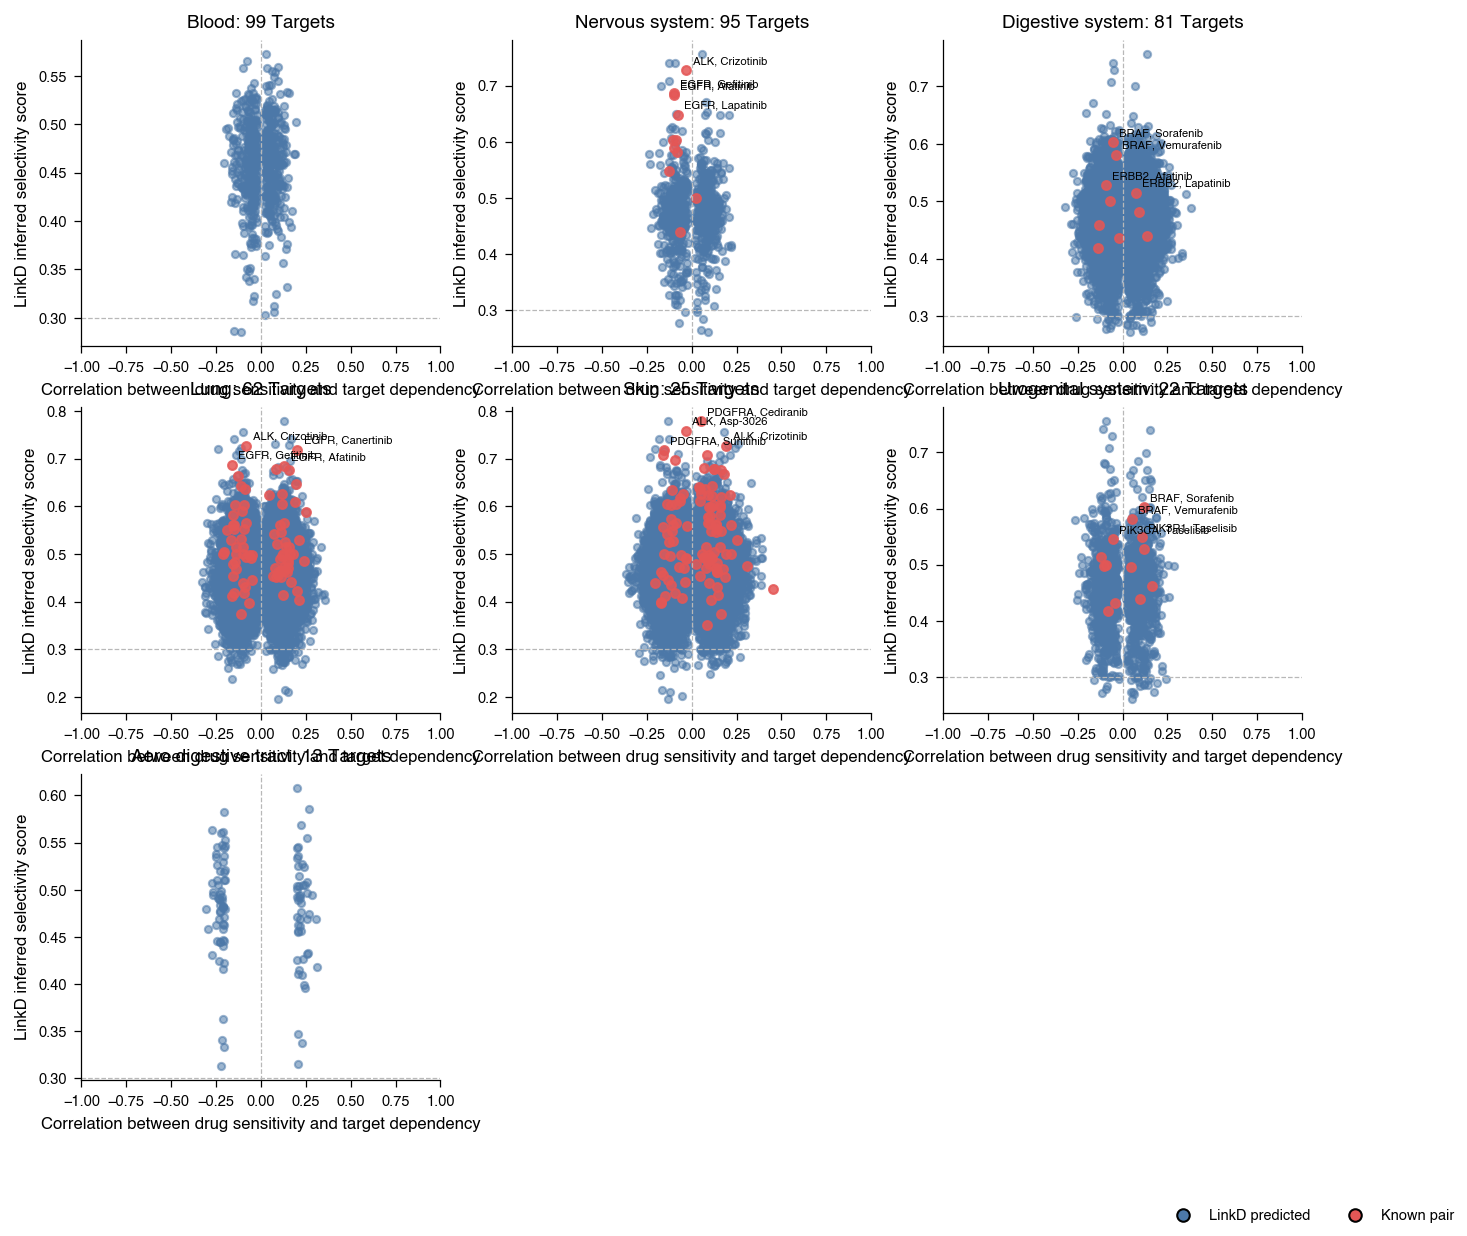

In [5]:
def scatter_pairs(ax: plt.Axes, data: pd.DataFrame, y: str, title: str, labels: int = 6) -> None:
    novel, known = data[~data["known"].astype(bool)], data[data["known"].astype(bool)]
    ax.scatter(novel["correlation"], novel[y], s=12, color=BLUE, alpha=.55, rasterized=True)
    ax.scatter(known["correlation"], known[y], s=18, color=RED, alpha=.85, rasterized=True)
    ax.axvline(0, color=GREY, lw=.6, ls="--")
    if y == "selectivity": ax.axhline(.30, color=GREY, lw=.6, ls="--")
    ax.set_xlim(-1, 1); ax.set_title(title)
    ax.set_xlabel("Correlation between drug sensitivity and target dependency")
    for _, row in known.sort_values([y, "correlation"], ascending=False).head(labels).iterrows():
        ax.annotate(f"{row['gene']}, {str(row['drug_name']).title()}",
                    (row["correlation"], row[y]), xytext=(3, 3),
                    textcoords="offset points", fontsize=5.4)


def plot_tissue(data: pd.DataFrame, selectivity: bool) -> tuple[plt.Figure, pd.DataFrame]:
    tissues = list(TISSUE_TARGETS)
    if selectivity: tissues = [t for t in tissues if t != "Breast"]
    fig, axes = plt.subplots(3, 3, figsize=(10.5, 9 if selectivity else 9.5))
    for ax, tissue in zip(axes.flat, tissues):
        sub = data[data["tissue"] == tissue]
        scatter_pairs(ax, sub, "selectivity" if selectivity else "affinity",
                       f"{tissue}: {TISSUE_TARGETS[tissue]} Targets", labels=4)
        ax.set_ylabel("LinkD inferred selectivity score" if selectivity else "LinkD predicted binding affinity")
    for ax in axes.flat[len(tissues):]: ax.set_axis_off()
    handles = [Line2D([], [], marker="o", color="none", markerfacecolor=BLUE, label="LinkD predicted"),
               Line2D([], [], marker="o", color="none", markerfacecolor=RED, label="Known pair")]
    fig.legend(handles=handles, frameon=False, ncol=2, loc="lower right")
    return fig, data


def plot_figs3(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    return plot_tissue(data, False)


def plot_figs4(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    return plot_tissue(data, True)


figure, plotted_source = plot_figs4(prepared)
display(figure)
plt.close(figure)

In [6]:
pdf_path = OUTPUT_FIG / "figS4_tissue_selectivity.pdf"
png_path = OUTPUT_FIG / "figS4_tissue_selectivity.png"
csv_path = OUTPUT_DATA / "figS4_tissue_selectivity.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "figS4_tissue_selectivity", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: All submitted non-breast panels are shown.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS4_tissue_selectivity.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS4_tissue_selectivity.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/figS4_tissue_selectivity.csv
Panel result: All submitted non-breast panels are shown.


## Complete

All submitted panels assigned to this notebook were reproduced.
